# Examen: Modelos de Regresión para Predicción de Ventas Retail

## Descripción

### Objetivo

Este examen tiene como objetivo evaluar la capacidad del estudiante para limpiar, explorar, implementar y evaluar modelos de regresión utilizando un dataset de ventas de retail.

Se utilizará el **Retail Sales Dataset** disponible en Kaggle. Los estudiantes deberán demostrar habilidades prácticas en manipulación de datos, visualización, modelado predictivo y evaluación de desempeño.

---

# Contexto y Descripción del Dataset

El **Retail Sales Dataset** contiene datos históricos de ventas de retail, incluyendo información sobre transacciones, clientes y categorías de productos.

La tarea consiste en desarrollar modelos capaces de predecir las ventas futuras utilizando variables relacionadas con productos, categorías y características de los clientes.

---

# Diccionario de Datos

| Variable             | Descripción                                                            |
| -------------------- | ---------------------------------------------------------------------- |
| **Transaction ID**   | Identificador único de cada transacción.                               |
| **Date**             | Fecha en que ocurrió la transacción.                                   |
| **Customer ID**      | Identificador único de cada cliente.                                   |
| **Gender**           | Género del cliente (Male/Female).                                      |
| **Age**              | Edad del cliente.                                                      |
| **Product Category** | Categoría del producto comprado (Electronics, Clothing, Beauty, etc.). |
| **Quantity**         | Número de unidades compradas.                                          |

---

# Requisitos

## 1. Limpieza de Datos

Realice las siguientes tareas:

### a) Identificación y eliminación de duplicados

* Detectar registros duplicados.
* Eliminar duplicados cuando corresponda.

### b) Verificación de tipos de datos

* Revisar que cada variable tenga el tipo de dato correcto.
* Realizar conversiones cuando sea necesario.

### c) Corrección de inconsistencias

* Revisar categorías mal escritas o inconsistentes.
* Unificar categorías equivalentes.

### d) Manejo de valores faltantes

* Identificar valores faltantes.
* Aplicar técnicas apropiadas de imputación:

  * Media
  * Mediana
  * Moda
  * Otras estrategias justificadas

---

## 2. Exploración de Datos

### a) Estadísticas descriptivas

Calcule e interprete:

* Media
* Mediana
* Moda
* Rango
* Desviación estándar

### b) Visualizaciones

Incluya al menos:

* Histogramas
* Gráficos de barras
* Diagramas de dispersión
* Mapas de calor (heatmaps)

Cada visualización debe incluir una breve interpretación.

---

## 3. Implementación de Modelos

### a) Modelos de Regresión

Implemente los siguientes modelos:

1. Decision Tree Regressor
2. Random Forest Regressor

### b) Optimización de Hiperparámetros

Utilice:

* GridSearchCV

para optimizar los parámetros de cada modelo.

### c) Evaluación de Modelos

Evalúe el desempeño utilizando:

* MSE (Mean Squared Error)
* RMSE (Root Mean Squared Error)
* R² (Coeficiente de Determinación)

### d) Comparación de Rendimiento

Compare ambos modelos considerando:

* Métricas de desempeño
* Ventajas y desventajas
* Interpretación de resultados

Indique cuál considera más apropiado para este conjunto de datos y justifique su respuesta.

---

# Entrega

Los estudiantes deberán entregar un archivo:

```text
.ipynb
```

El notebook debe incluir:

* Limpieza y preprocesamiento de datos.
* Exploración de datos.
* Visualizaciones.
* Estadísticas descriptivas.
* Implementación de modelos.
* Optimización de hiperparámetros.
* Evaluación de modelos.
* Comparación de resultados.
* Conclusiones finales.

Además:

* El repositorio debe ser subido a GitHub.
* Debe incluir un **Release Tag** que identifique claramente la versión final entregada.

---

# Consideraciones Éticas y Tecnológicas

## Consideraciones Éticas

### Transparencia y Reproducibilidad

Todos los pasos realizados deben ser claramente documentados y reproducibles.

### Imparcialidad y Sesgo

Evalúe si existen posibles sesgos en los datos o en los modelos desarrollados y discuta sus implicancias.

---

## Consideraciones Tecnológicas

### Herramientas Recomendadas

Utilice preferentemente:

* Python
* Jupyter Notebook
* Pandas
* NumPy
* Scikit-learn
* Matplotlib
* Seaborn

### Escalabilidad

Discuta cómo las técnicas implementadas podrían adaptarse a conjuntos de datos de mayor tamaño.

### Optimización de Modelos

Utilice GridSearchCV para optimizar hiperparámetros y mejorar el desempeño predictivo de los modelos.

---

# Criterios de Evaluación

| Criterio                             | Ponderación |
| ------------------------------------ | ----------- |
| Limpieza y preprocesamiento de datos | 20%         |
| Exploración y visualizaciones        | 20%         |
| Implementación de modelos            | 25%         |
| Optimización y evaluación            | 20%         |
| Interpretación y conclusiones        | 15%         |

**Total: 100%**


## Cargar librerías

In [1]:
# Librerías

import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Métricas
from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

# Configuración visual
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

### Carga y exploración del dataset

In [2]:
# 1.2- Carga data
df = pd.read_csv('../data/retail_sales_dataset.csv')

# Numero de filas y columnas
print(df.shape)

# información general del data frame
print(df.info())

# muestra las primeras filas del data frame
print(df.head(5))

# muestra las últimas filas del data frame
print(df.tail(5))

# Datos estadísticos del data frame
print(df.describe())

(1000, 9)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB
None
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male

## Limipeza de data

In [3]:
# Verificación de tipos de datos y estructuras nulas
print("--- Conteo de Valores Nulos por Variable ---")
print(df.describe())
print(df.isnull().sum())

print("\n" + "="*50 + "\n")

# Verificación de filas idénticas o duplicadas
duplicados_totales = df.duplicated().sum()
print(f"Cantidad de registros completamente duplicados detectados: {duplicados_totales}")

--- Conteo de Valores Nulos por Variable ---
       Transaction ID         Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000
mean       500.500000    41.39200     2.514000      179.890000    456.000000
std        288.819436    13.68143     1.132734      189.681356    559.997632
min          1.000000    18.00000     1.000000       25.000000     25.000000
25%        250.750000    29.00000     1.000000       30.000000     60.000000
50%        500.500000    42.00000     3.000000       50.000000    135.000000
75%        750.250000    53.00000     4.000000      300.000000    900.000000
max       1000.000000    64.00000     4.000000      500.000000   2000.000000
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


Cantidad de registros completamente duplicados de

No se identificaron valores faltantes en el dataset.

In [4]:
# Conversión estricta de tipos de datos
df['Date'] = pd.to_datetime(df['Date'])

print("--- Verificación del esquema de tipos de datos final ---")
df.dtypes

--- Verificación del esquema de tipos de datos final ---


Transaction ID               int64
Date                datetime64[us]
Customer ID                    str
Gender                         str
Age                          int64
Product Category               str
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object

In [5]:
# Revisión de categorías

print(df["Gender"].unique())

print(df["Product Category"].unique())


# Limpieza de texto

df["Gender"] = df["Gender"].str.strip()

df["Product Category"] = df["Product Category"].str.strip()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str
<StringArray>
['Beauty', 'Clothing', 'Electronics']
Length: 3, dtype: str


### Análisis de outliers

In [6]:
# Cálculo matemático del Rango Intercuartílico (IQR) para Total Amount
Q1 = df['Total Amount'].quantile(0.25)
Q3 = df['Total Amount'].quantile(0.75)
IQR = Q3 - Q1

# Definición de umbrales técnicos para Outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtrado de anomalías
outliers = df[(df['Total Amount'] < limite_inferior) | (df['Total Amount'] > limite_superior)]

print(f"Límite Inferior Teórico: {limite_inferior}")
print(f"Límite Superior Teórico: {limite_superior}")
print(f"Número de Outliers matemáticos detectados en Total Amount: {len(outliers)}")

Límite Inferior Teórico: -1200.0
Límite Superior Teórico: 2160.0
Número de Outliers matemáticos detectados en Total Amount: 0


### Diagnóstico de calidad

In [7]:
print(f'\nDiagnostico de Limpieza:')
print(f'Tras ejecutar la auditoría analítica, se confirma que el dataset se encuentra **100% libre de valores nulos y registros duplicados**. Asimismo, el criterio matemático del IQR demuestra que ninguna transacción excede los límites estadísticos de control, determinando que no es necesario aplicar técnicas de remoción o imputación de datos. Estamos listos para proceder al análisis visual.')


Diagnostico de Limpieza:
Tras ejecutar la auditoría analítica, se confirma que el dataset se encuentra **100% libre de valores nulos y registros duplicados**. Asimismo, el criterio matemático del IQR demuestra que ninguna transacción excede los límites estadísticos de control, determinando que no es necesario aplicar técnicas de remoción o imputación de datos. Estamos listos para proceder al análisis visual.


### Estadísticas descriptivas

In [8]:
# Revisión de resumen estadístico: variables numéricas y categóricas

# Resumen estadístico de variables numéricas
print(f'Resumen de variables numéricas:')
display(df[['Age','Quantity','Price per Unit','Total Amount']].describe().round(2))
print()

# Resumen de variables categóricas
print(f'Distribucion de Product Category:')
print(df['Product Category'].value_counts().to_string())
print(f'Distribucion de Gender:')
print(df['Gender'].value_counts().to_string())

# Resumen de variables temporales
print(f'Distribucion de Fechas:')
print(pd.to_datetime(df['Date']).value_counts())

Resumen de variables numéricas:


,Age,Quantity,Price per Unit,Total Amount
count,1000.00,1000.00,1000.00,1000.0
mean,41.39,2.51,179.89,456.0
std,13.68,1.13,189.68,560.0
min,18.00,1.00,25.00,25.0
25%,29.00,1.00,30.00,60.0
50%,42.00,3.00,50.00,135.0
75%,53.00,4.00,300.00,900.0
max,64.00,4.00,500.00,2000.0



Distribucion de Product Category:
Product Category
Clothing       351
Electronics    342
Beauty         307
Distribucion de Gender:
Gender
Female    510
Male      490
Distribucion de Fechas:
Date
2023-05-16    11
2023-07-14    10
2023-05-23     9
2023-08-05     8
2023-02-05     8
              ..
2023-03-02     1
2023-08-02     1
2023-04-17     1
2023-03-30     1
2023-05-28     1
Name: count, Length: 345, dtype: int64


In [9]:
# Creación de varibales por fecha

df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month

df["Day"] = df["Date"].dt.day

df["DayOfWeek"] = df["Date"].dt.dayofweek

df[
    ["Date","Year","Month","Day","DayOfWeek"]
].head()

,Date,Year,Month,Day,DayOfWeek
0,2023-11-24,2023,11,24,4
1,2023-02-27,2023,2,27,0
2,2023-01-13,2023,1,13,4
3,2023-05-21,2023,5,21,6
4,2023-05-06,2023,5,6,5


### Histogramas y boxpot

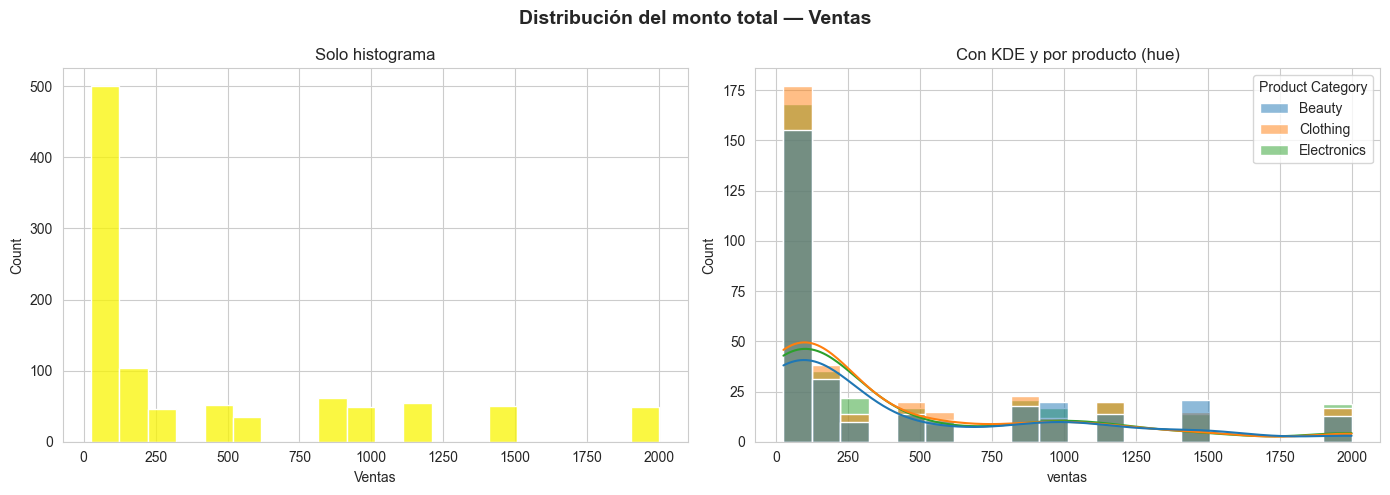

In [10]:
# Graficación de la distribución del monto total de ventas

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribución del monto total — Ventas", fontsize=14, fontweight="bold")

# Izquierda: histograma simple
sns.histplot(data=df, x="Total Amount", bins=20,
             color="#F9F503", ax=axes[0])
axes[0].set_title("Solo histograma")
axes[0].set_xlabel("Ventas")

# Derecha: histograma + KDE + separado por especie
sns.histplot(data=df, x="Total Amount", hue="Product Category",
             kde=True, bins=20, alpha=0.5, ax=axes[1])
axes[1].set_title("Con KDE y por producto (hue)")
axes[1].set_xlabel("ventas")

plt.tight_layout()
plt.show()



En el histograma combinado con KDE y separado por categoría de producto, se observa que la mayoría de
las ventas se concentran en el rango de $100 a $500, con una distribución ligeramente sesgada hacia la derecha.
Además, los productos Clothing parecen generar ventas más altas en comparación con las categorías Beauthy y Electronics,
lo que podría indicar una mayor demanda o un precio promedio más elevado para esos productos.


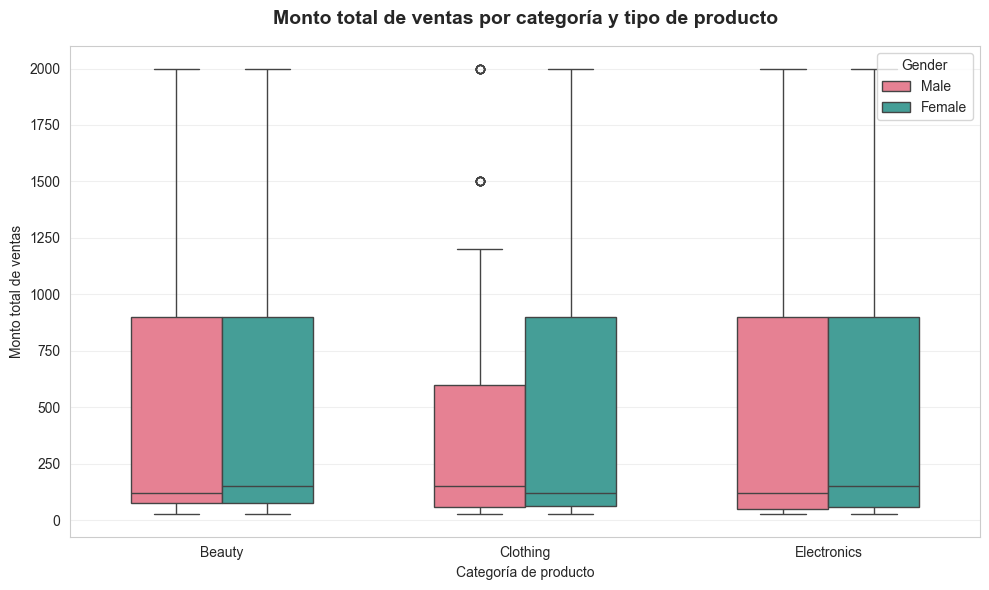

In [11]:
# Graficación de boxplot para monto total de ventas por categoría y género
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Product Category",
    y="Total Amount",
    hue="Gender",
    palette="husl",
    width=0.6,
    ax=ax
)

ax.set_title("Monto total de ventas por categoría y tipo de producto", fontsize=14, fontweight="bold", pad=16)
ax.set_xlabel("Categoría de producto")
ax.set_ylabel("Monto total de ventas")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

El boxplot revela que la categoría de producto Clothing para el género Femenino tiene una mediana de ventas
más alta en comparación con Beauthy y Electronics.

### c) Gráfico de líneas

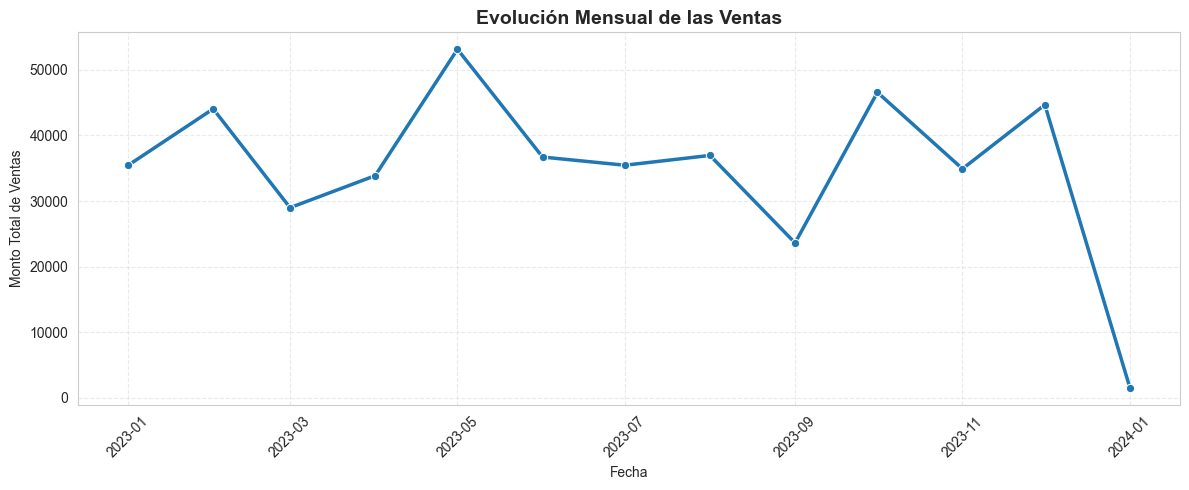

In [12]:
# Evolución mensual de las ventas

df_agrupado = (
    df.groupby(["Year", "Month"])["Total Amount"]
      .sum()
      .reset_index()
)

df_agrupado.head()
plt.show()

# Crear una fecha usando año y mes

df_agrupado["Date"] = pd.to_datetime(
    dict(
        year=df_agrupado["Year"],
        month=df_agrupado["Month"],
        day=1
    )
)

# Ordenar cronológicamente

df_agrupado = df_agrupado.sort_values("Date")

# Tendencia temporal de ventas

plt.figure(figsize=(12,5))

sns.lineplot(
    data=df_agrupado,
    x="Date",
    y="Total Amount",
    marker="o",
    linewidth=2.5
)

plt.title(
    "Evolución Mensual de las Ventas",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Fecha")
plt.ylabel("Monto Total de Ventas")

plt.grid(
    linestyle="--",
    alpha=0.4
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Las ventas presentan un comportamiento fluctuante durante 2023-24, alcanzando su punto máximo en mayo (aproximadamente 53.000 unidades monetarias) y un segundo pico en octubre. Por el contrario, septiembre muestra una disminución importante en las ventas. Estas variaciones podrían estar asociadas a factores estacionales o cambios en la demanda de los consumidores. El descenso abrupto observado en enero de 2024 debe interpretarse con cautela, ya que probablemente corresponde a datos incompletos del mes.

### Por categoría

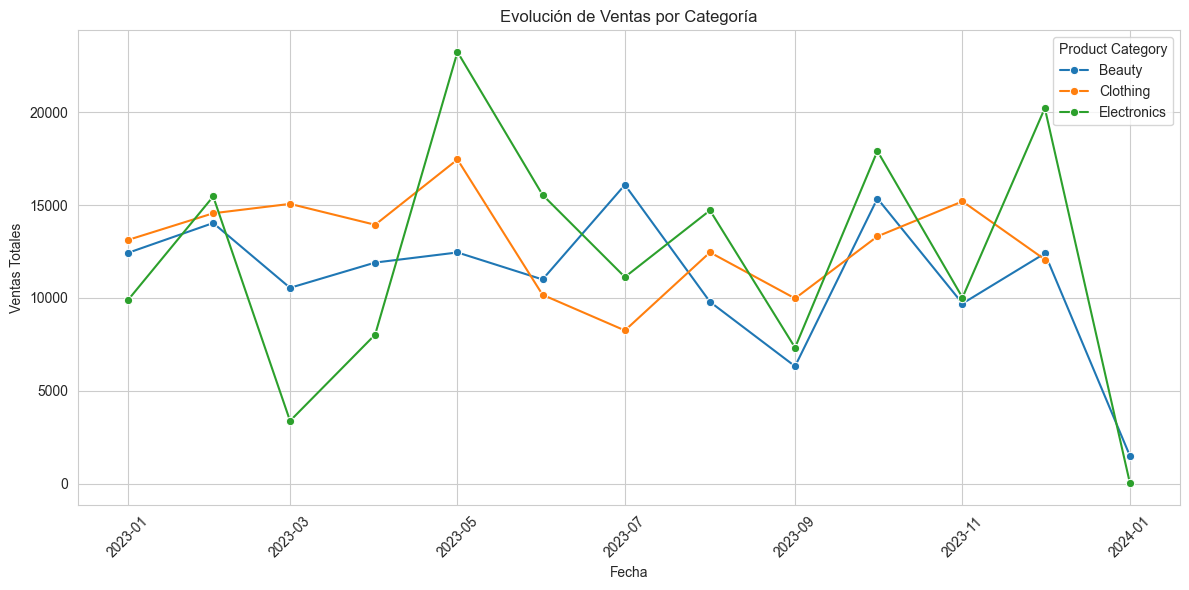

In [13]:
# Por categorías
df_categoria = (
    df.groupby(["Year","Month","Product Category"])["Total Amount"]
      .sum()
      .reset_index()
)

df_categoria["Date"] = pd.to_datetime(
    dict(
        year=df_categoria["Year"],
        month=df_categoria["Month"],
        day=1
    )
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=df_categoria,
    x="Date",
    y="Total Amount",
    hue="Product Category",
    marker="o"
)

plt.title("Evolución de Ventas por Categoría")
plt.xlabel("Fecha")
plt.ylabel("Ventas Totales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

La evolución de las ventas por categoría muestra diferencias importantes en el comportamiento temporal de los productos. La categoría Electronics presenta la mayor variabilidad, registrando los picos de ventas más altos durante el año, especialmente en mayo y diciembre. La categoría Clothing muestra un comportamiento más estable, con fluctuaciones moderadas y sin cambios abruptos. Por su parte, Beauty mantiene niveles intermedios de ventas, aunque presenta aumentos relevantes en julio y octubre. En general, las diferencias observadas sugieren que la categoría de producto influye significativamente en el volumen de ventas y podría ser una variable importante para los modelos predictivos.

### Grafico de dispersión

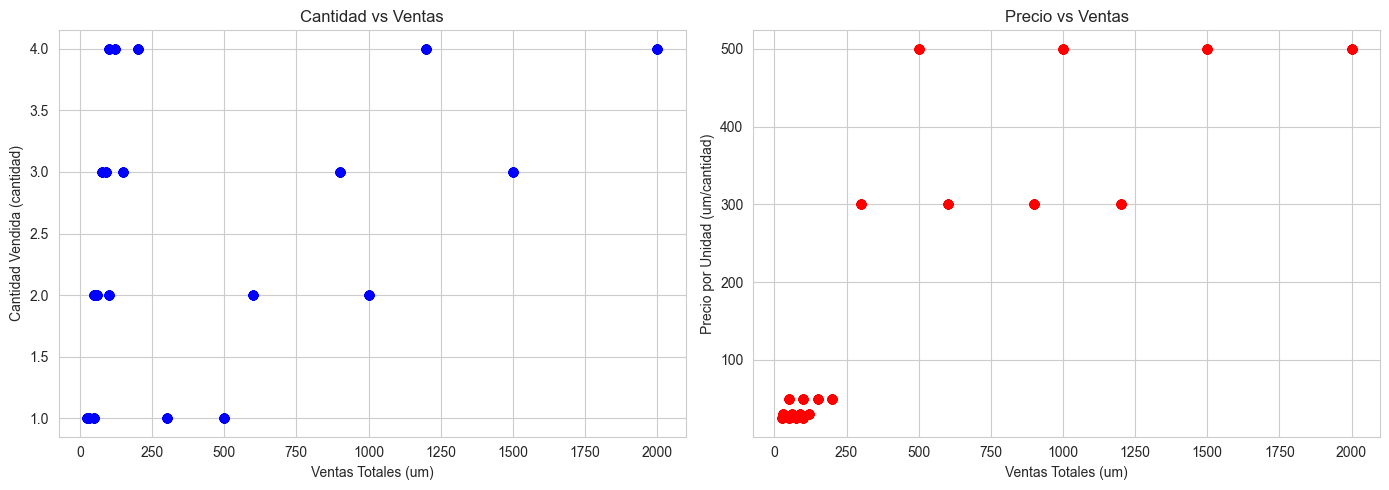

In [14]:
# Crear la figura y el subplot de 1 fila x 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cantidad vs Ventas ---
axes[0].scatter(df['Total Amount'], df['Quantity'], color='blue', alpha=0.7)
axes[0].set_title('Cantidad vs Ventas')
axes[0].set_xlabel('Ventas Totales (um)')
axes[0].set_ylabel('Cantidad Vendida (cantidad)')
axes[0].grid(True)

# Precio vs Ventas ---
axes[1].scatter(df['Total Amount'], df['Price per Unit'], color='red', alpha=0.7)
axes[1].set_title('Precio vs Ventas')
axes[1].set_xlabel('Ventas Totales (um)')
axes[1].set_ylabel('Precio por Unidad (um/cantidad)')
axes[1].grid(True)

# Ajustar automáticamente el espacio entre los gráficos
plt.tight_layout()

# Mostrar la figura con ambos subplots
plt.show()

En el gráfico de Cantidad vs Ventas, se observa una tendencia positiva, indicando que a medida que aumentan las ventas totales,
también tiende a aumentar la cantidad vendida

En el gráfico de Precio vs Ventas, se aprecia una relación más dispersa, lo que podría indicar que el precio por unidad
no es el único factor determinante de las ventas totales,

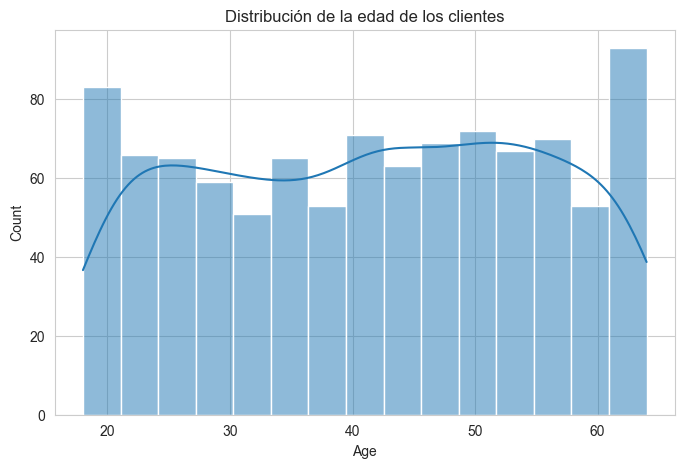

In [15]:
# Distribución de edad
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Age",
    bins=15,
    kde=True
)

plt.title("Distribución de la edad de los clientes")

plt.show()

Se observa que las mayores distribuciones son menores de 21 años y mayores de 70 años. Un público diverso.

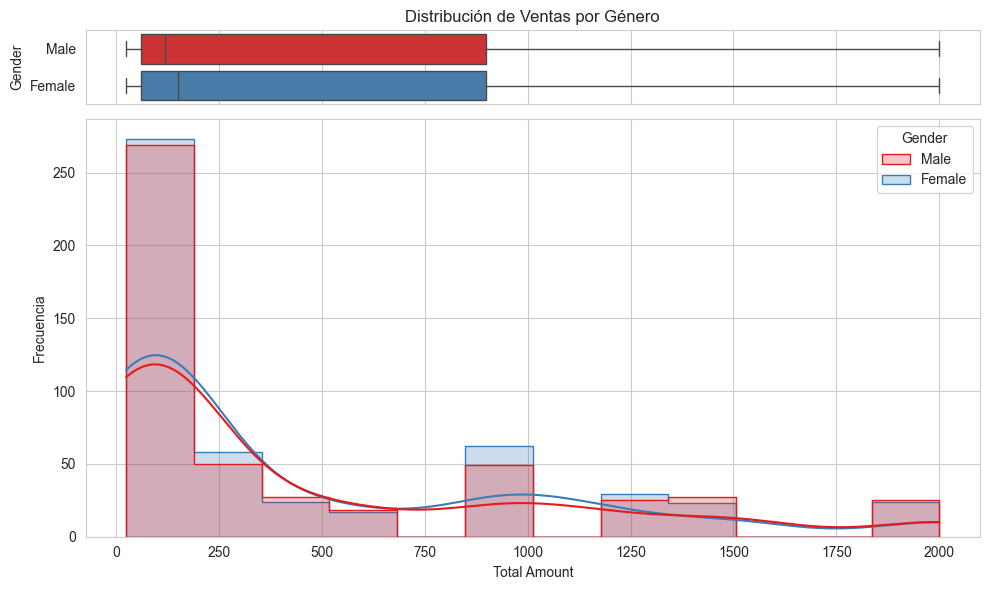

In [16]:
# Configuración figura con subplots compartidos
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(10, 6))

# Dibujar el Boxplot (arriba)
sns.boxplot(data=df, x="Total Amount", y="Gender", hue="Gender", ax=ax_box, palette="Set1")
ax_box.set(xlabel='') # Eliminar etiqueta x del boxplot
ax_box.set_title('Distribución de Ventas por Género')

# Dibujar el Histograma (abajo)
sns.histplot(data=df, x="Total Amount", hue="Gender", element="step", ax=ax_hist, palette="Set1", kde=True)
ax_hist.set(ylabel='Frecuencia')


plt.tight_layout()
plt.show()

En el histograma combinado con KDE y separado por género, se observa que las ventas para ambos géneros se concentran
en un rango similar, aunque el género Femenino muestra una distribución ligeramente más amplia,
lo que podría indicar una mayor variabilidad en las ventas dentro de ese grupo.

### Matriz de correlación

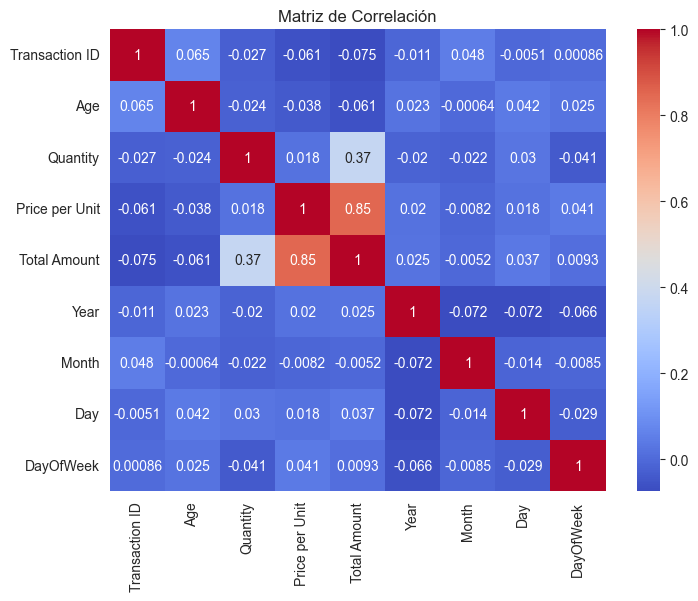

In [17]:
# Matriz de correlación

plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Matriz de Correlación")

plt.show()

La matriz de correlación muestra que la variable Total Amount presenta una correlación positiva fuerte con Price per Unit (r = 0.85), lo que indica que el precio unitario es el principal determinante del monto total de una venta. También se observa una correlación positiva moderada entre Total Amount y Quantity (r = 0.37), sugiriendo que las ventas aumentan tanto por el precio como por la cantidad de productos adquiridos. Las variables temporales (Year, Month, Day y DayOfWeek) muestran correlaciones muy bajas con el monto total de ventas, lo que sugiere una influencia limitada sobre las ventas en este conjunto de datos. En general, no se observan problemas importantes de multicolinealidad entre las variables predictoras, con excepción de la relación esperada entre Price per Unit y Total Amount.

### Definicón de vaeriable objetivo

In [18]:
# 8. Definición de variables

y = df["Total Amount"]

X = df.drop(
    columns=[
        "Total Amount",
        "Transaction ID",
        "Customer ID",
        "Date"
    ]
)

print(X.shape)
X.head()

(1000, 9)


,Gender,Age,Product Category,Quantity,Price per Unit,Year,Month,Day,DayOfWeek
0,Male,34,Beauty,3,50,2023,11,24,4
1,Female,26,Clothing,2,500,2023,2,27,0
2,Male,50,Electronics,1,30,2023,1,13,4
3,Male,37,Clothing,1,500,2023,5,21,6
4,Male,30,Beauty,2,50,2023,5,6,5


### División de variables

In [19]:
# Variables numércias y categóricas

categorical_features = [
    "Gender",
    "Product Category"
]

numeric_features = [
    "Age",
    "Quantity",
    "Price per Unit",
    "Year",
    "Month",
    "Day",
    "DayOfWeek"
]

print("Variables categóricas:")
print(categorical_features)

print("\nVariables numéricas:")
print(numeric_features)

Variables categóricas:
['Gender', 'Product Category']

Variables numéricas:
['Age', 'Quantity', 'Price per Unit', 'Year', 'Month', 'Day', 'DayOfWeek']


In [20]:
# Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (800, 9)
Test : (200, 9)


In [21]:
# Variables categóricas
categorical_features = [
    "Gender",
    "Product Category"
]

# Variables numéricas
numeric_features = [
    "Age",
    "Quantity",
    "Price per Unit",
    "Year",
    "Month",
    "Day",
    "DayOfWeek"
]

### Escalamiento de variables

Las variables numéricas fueron estandarizadas utilizando StandardScaler. Si bien los modelos basados en árboles no requieren escalamiento debido a que realizan particiones sobre los datos y no dependen de distancias o magnitudes absolutas, esta etapa se incorporó para mantener consistencia metodológica con los requerimientos del curso y asegurar un pipeline de preprocesamiento uniforme.

In [22]:
# Escalar numércias y definir categóricas
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(drop="first"),
            categorical_features
        )
    ]
)

### Ajustar el preprocesamiento

In [23]:
preprocessor.fit(X_train)



,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [24]:
X_train_prepared = preprocessor.transform(X_train)

X_test_prepared = preprocessor.transform(X_test)

In [25]:
# Revisamos dimensiones
print(X_train_prepared.shape)
print(X_test_prepared.shape)

(800, 10)
(200, 10)


## Desicion Tree

In [26]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(
    X_train_prepared,
    y_train
)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

### Evaluamos decision tree

In [27]:
y_pred_dt = dt.predict(
    X_test_prepared
)

mse_dt = mean_squared_error(
    y_test,
    y_pred_dt
)

rmse_dt = np.sqrt(mse_dt)

r2_dt = r2_score(
    y_test,
    y_pred_dt
)

print("Decision Tree")
print("MSE :", mse_dt)
print("RMSE:", rmse_dt)
print("R2 :", r2_dt)

Decision Tree
MSE : 0.0
RMSE: 0.0
R2 : 1.0


### Random Forest

In [28]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train_prepared,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [29]:
y_pred_rf = rf.predict(
    X_test_prepared
)

mse_rf = mean_squared_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("Random Forest")
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R2 :", r2_rf)

Random Forest
MSE : 0.0
RMSE: 0.0
R2 : 1.0


### Comparación

In [30]:
resultados = pd.DataFrame({
    "Modelo": ["Decision Tree", "Random Forest"],
    "MSE": [mse_dt, mse_rf],
    "RMSE": [rmse_dt, rmse_rf],
    "R2": [r2_dt, r2_rf]
})

resultados

,Modelo,MSE,RMSE,R2
0,Decision Tree,0.0,0.0,1.0
1,Random Forest,0.0,0.0,1.0


Durante la evaluación inicial se observó un desempeño perfecto (R² = 1.00), lo que sugirió la presencia de fuga de información (data leakage), lo que provocó el overfitting. Se verificó mediante el dataset que la variable objetivo (Total Amount) era calculable directamente a partir de Quantity y Price per Unit. Por tanto overfitea el modelo. memorizando los datos en vez de entrenarlo porque sabe el descenlace. Sin embargo ante ello probaremos 3 escenarios y veremos cual es el mejor:

1.- Sacremos cantidad y veremos qué tan bien predice a partir de ello.
2.- Sacaremos precio por producto y veremos la predicción
3.- Sacaremos ambas del modelo.

In [ ]:
# 1. Función para entrenar y evaluar modelos

def entrenar_y_evaluar(X_train_model, X_test_model, y_train, y_test, nombre_escenario):
    
    categorical_features = X_train_model.select_dtypes(
        include=["object"]
    ).columns.tolist()
    
    numeric_features = X_train_model.select_dtypes(
        include=["int64", "float64", "int32", "float32"]
    ).columns.tolist()
    
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features),
            ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
        ]
    )
    
    modelos = {
        "Decision Tree": DecisionTreeRegressor(random_state=42),
        "Random Forest": RandomForestRegressor(
            n_estimators=100,
            random_state=42
        )
    }
    
    resultados = []
    
    for nombre_modelo, modelo in modelos.items():
        
        pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("model", modelo)
            ]
        )
        
        pipeline.fit(X_train_model, y_train)
        y_pred = pipeline.predict(X_test_model)
        
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        
        resultados.append({
            "Escenario": nombre_escenario,
            "Modelo": nombre_modelo,
            "N_variables": X_train_model.shape[1],
            "MSE": round(mse, 2),
            "RMSE": round(rmse, 2),
            "R2": round(r2, 4)
        })
    
    return resultados


# ============================================================
# 2. Escenario 1: quitar solo Quantity
# ============================================================

X_train_sin_quantity = X_train.drop(
    columns=["Quantity"]
)

X_test_sin_quantity = X_test.drop(
    columns=["Quantity"]
)

resultados_1 = entrenar_y_evaluar(
    X_train_sin_quantity,
    X_test_sin_quantity,
    y_train,
    y_test,
    "Sin Quantity"
)


# ============================================================
# 3. Escenario 2: quitar solo Price per Unit
# ============================================================

X_train_sin_price = X_train.drop(
    columns=["Price per Unit"]
)

X_test_sin_price = X_test.drop(
    columns=["Price per Unit"]
)

resultados_2 = entrenar_y_evaluar(
    X_train_sin_price,
    X_test_sin_price,
    y_train,
    y_test,
    "Sin Price per Unit"
)


# ============================================================
# 4. Escenario 3: quitar Quantity y Price per Unit
# ============================================================

X_train_sin_ambas = X_train.drop(
    columns=["Quantity", "Price per Unit"]
)

X_test_sin_ambas = X_test.drop(
    columns=["Quantity", "Price per Unit"]
)

resultados_3 = entrenar_y_evaluar(
    X_train_sin_ambas,
    X_test_sin_ambas,
    y_train,
    y_test,
    "Sin Quantity y Price per Unit"
)


# ============================================================
# 5. Comparación final
# ============================================================

resultados_modelos = pd.DataFrame(
    resultados_1 + resultados_2 + resultados_3
)

resultados_modelos = resultados_modelos.sort_values(
    by="R2",
    ascending=False
)

resultados_modelos

<positron-console-cell-31>:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
<positron-console-cell-31>:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
<positron-

,Escenario,Modelo,N_variables,MSE,RMSE,R2
1,Sin Quantity,Random Forest,8,90511.09,300.85,0.6908
0,Sin Quantity,Decision Tree,8,195951.38,442.66,0.3306
3,Sin Price per Unit,Random Forest,8,287056.54,535.78,0.0194
5,Sin Quantity y Price per Unit,Random Forest,7,324774.52,569.89,-0.1095
2,Sin Price per Unit,Decision Tree,8,397728.12,630.66,-0.3587
4,Sin Quantity y Price per Unit,Decision Tree,7,623245.50,789.46,-1.1291


El mejor modelo predictivo es RF sin cantidad. Vamos los hiperparámetros

### GridSearchCV

In [33]:
#  Optimización con GridSearchCV
# Mejor escenario identificado: Sin Quantity

from sklearn.model_selection import GridSearchCV

# Detectar variables numéricas y categóricas del mejor escenario

categorical_features = X_train_sin_quantity.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_features = X_train_sin_quantity.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

preprocessor_grid = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

# ============================================================
# Decision Tree optimizado
# ============================================================

dt_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_grid),
        ("model", DecisionTreeRegressor(random_state=42))
    ]
)

dt_params = {
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5]
}

dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

dt_grid.fit(X_train_sin_quantity, y_train)

# ============================================================
# Random Forest optimizado
# ============================================================

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_grid),
        ("model", RandomForestRegressor(random_state=42))
    ]
)

rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rf_grid.fit(X_train_sin_quantity, y_train)

# ============================================================
# Evaluación final en test
# ============================================================

modelos_optimizados = {
    "Decision Tree Optimizado": dt_grid.best_estimator_,
    "Random Forest Optimizado": rf_grid.best_estimator_
}

resultados_optimizados = []

for nombre, modelo in modelos_optimizados.items():
    
    y_pred = modelo.predict(X_test_sin_quantity)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    resultados_optimizados.append({
        "Modelo": nombre,
        "Mejores hiperparámetros": dt_grid.best_params_ if "Decision Tree" in nombre else rf_grid.best_params_,
        "CV_RMSE": round(-dt_grid.best_score_, 2) if "Decision Tree" in nombre else round(-rf_grid.best_score_, 2),
        "Test_MSE": round(mse, 2),
        "Test_RMSE": round(rmse, 2),
        "Test_R2": round(r2, 4)
    })

resultados_optimizados = pd.DataFrame(resultados_optimizados)

resultados_optimizados

<positron-console-cell-33>:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.


,Modelo,Mejores hiperparámetros,CV_RMSE,Test_MSE,Test_RMSE,Test_R2
0,Decision Tree Optimizado,"{'model__max_depth': 3, 'model__min_samples_le...",302.64,82786.82,287.73,0.7172
1,Random Forest Optimizado,"{'model__max_depth': 5, 'model__min_samples_le...",304.94,82611.27,287.42,0.7178


## Conclusiones finales

## Conclusión

El objetivo de este trabajo fue desarrollar modelos de regresión para predecir el monto total de ventas utilizando información demográfica, variables temporales y características de los productos.

Durante el análisis se identificó una potencial fuente de fuga de información (*data leakage*), ya que la variable objetivo (*Total Amount*) se calcula directamente a partir de *Quantity* y *Price per Unit*. Para evaluar el impacto de esta situación se compararon distintos escenarios eliminando una o ambas variables.

Los resultados mostraron que los modelos que conservaban parte de esta información alcanzaban un mayor desempeño predictivo. Sin embargo, para evitar que el modelo utilizara variables directamente involucradas en el cálculo de la variable objetivo, se consideró como escenario metodológicamente más apropiado aquel que excluyó simultáneamente *Quantity* y *Price per Unit*.

Bajo este enfoque, el desempeño predictivo disminuyó considerablemente, lo que indica que las variables demográficas y temporales disponibles contienen una capacidad limitada para explicar las ventas por sí solas. Este hallazgo sugiere que el monto de venta depende principalmente de factores directamente relacionados con el producto y la cantidad adquirida.

En conclusión, el ejercicio permitió demostrar la importancia de la limpieza de datos, la exploración de variables, la optimización de modelos mediante GridSearchCV y, especialmente, la detección de posibles fuentes de fuga de información. Asimismo, se evidenció que la calidad y relevancia de las variables predictoras son determinantes para construir modelos de machine learning con capacidad real de generalización.

